# CNN *from scratch* vs Transfert d'apprentissage — Cats vs Dogs

**Devoir Deep Learning — Master 1 IA (DIT)**

## Objectif

Comparer, sur **exactement le même jeu de données** (chats vs chiens) et **le même protocole d'évaluation** :

| | Expérience A | Expérience B |
|---|---|---|
| Modèle | CNN simple **from scratch** (4 blocs conv + BN) | **ResNet-18 pré-entraîné ImageNet**, tête de classification remplacée |
| Régularisation | BatchNorm (après chaque conv) + Dropout (tête) | BatchNorm + Dropout dans la nouvelle tête (le backbone contient déjà du BN) |
| Optimiseurs testés | Adam **et** SGD (momentum + Nesterov) | Adam **et** SGD |
| Learning rate | recherche sur grille (essais courts) + scheduler cosinus | idem (LR de la tête ; backbone à LR/10) |

On mesure l'impact du transfert learning sur :
1. la **convergence** (vitesse d'apprentissage),
2. la **performance** (accuracy, précision, recall, F1 sur un test jamais vu pendant la sélection),
3. la **robustesse** (dégradation sous flou, bruit, faible luminosité, rotation, basse résolution).

## Plan du notebook

0. Environnement, chemins, GPU, seed
1. Données : split train / val / test, augmentation
2. Fonctions utilitaires : métriques, boucle d'entraînement, optimiseurs, schedulers
3. Architectures (A : from scratch, B : transfert) + justification BatchNorm / Dropout
4. Recherche du learning rate
5. Entraînements (5 runs : A×2 optimiseurs, B×2 optimiseurs, B « backbone gelé »)
6. Courbes (loss, accuracy, précision, recall — train et val)
7. **Rechargement du meilleur checkpoint** + évaluation finale sur le test
8. Matrices de confusion et erreurs typiques
9. Robustesse
10. Synthèse et analyse

## 0. Environnement, chemins, GPU et reproductibilité

In [ ]:
%matplotlib inline

import os, sys, json, time, random, shutil, copy, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import torchvision.transforms.functional as TF

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

warnings.filterwarnings("ignore", message=".*lr_scheduler.step.*")   # avertissement anodin avec GradScaler
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

### Configuration centrale

In [ ]:
CFG = dict(
    # --- reproductibilité ---
    seed=42,

    # --- données ---
    img_size=224,            # taille d'entrée (224 = standard ImageNet)
    batch_size=64,
    num_workers=2,           # Colab gratuit = 2 CPU
    val_ratio=0.2,           # part du train mise de côté pour la validation
    copy_data_to_local=True, # copie Drive -> disque local Colab (lecture ~10x plus rapide)

    # --- entraînement ---
    use_amp=True,            # précision mixte (GPU uniquement)
    weight_decay=1e-4,
    scheduler="cosine",      # "cosine" | "step" | "none"
    patience=None,           # nb d'époques sans amélioration ; None = désactivé

    # --- Expérience A : CNN from scratch ---
    epochs_scratch=15,
    dropout_scratch=0.5,

    # --- Expérience B : transfert learning ---
    tl_arch="resnet18",      # "resnet18" | "mobilenet_v2" | "efficientnet_b0"
    pretrained=True,         # poids ImageNet
    epochs_tl=6,
    dropout_tl=0.3,
    backbone_lr_mult=0.1,    # fine-tuning : LR du backbone = LR de la tête x 0.1

    # --- recherche de learning rate ---
    lr_search_epochs=4,
    lr_search_train_size=2000,
    lr_search_val_size=1000,

    # --- confort ---
    reuse_existing=True,     # ne pas ré-entraîner un run déjà terminé (utile si Colab se déconnecte)
    quick_run=False,         # True = mini-run de vérification du pipeline (données et époques réduites)
    quick_train_size=1500, quick_val_size=500, quick_test_size=500,
)

if CFG["quick_run"]:
    CFG.update(epochs_scratch=2, epochs_tl=2, lr_search_epochs=1,
               lr_search_train_size=256, lr_search_val_size=128, reuse_existing=False)

# ------------------------- chemins -------------------------
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/Deep Learning/cnn_cat_dog_image_classification")
else:
    PROJECT_DIR = Path(os.environ.get("PROJECT_DIR", ".")).resolve()

SUFFIX = "_quick" if CFG["quick_run"] else ""
DRIVE_DATA_DIR = PROJECT_DIR / "Cat_Dog_data"
CHECKPOINT_DIR = PROJECT_DIR / f"checkpoints{SUFFIX}"   # modèles .pt   -> NON versionnés (.gitignore)
RUNS_DIR       = PROJECT_DIR / f"runs{SUFFIX}"          # TensorBoard    -> NON versionnés (.gitignore)
RESULTS_DIR    = PROJECT_DIR / f"results{SUFFIX}"       # historiques JSON / tableaux (légers)
FIGURES_DIR    = PROJECT_DIR / f"figures{SUFFIX}"       # figures PNG pour le README
for d in (CHECKPOINT_DIR, RUNS_DIR, RESULTS_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Projet     :", PROJECT_DIR)
print("Données    :", DRIVE_DATA_DIR)
print("Checkpoints:", CHECKPOINT_DIR)

Mounted at /content/drive
Projet     : /content/drive/MyDrive/Colab Notebooks/Deep Learning/cnn_cat_dog_image_classification
Données    : /content/drive/MyDrive/Colab Notebooks/Deep Learning/cnn_cat_dog_image_classification/Cat_Dog_data
Checkpoints: /content/drive/MyDrive/Colab Notebooks/Deep Learning/cnn_cat_dog_image_classification/checkpoints


In [ ]:
CFG

{'seed': 42,
 'img_size': 224,
 'batch_size': 64,
 'num_workers': 2,
 'val_ratio': 0.2,
 'copy_data_to_local': True,
 'use_amp': True,
 'weight_decay': 0.0001,
 'scheduler': 'cosine',
 'patience': None,
 'epochs_scratch': 15,
 'dropout_scratch': 0.5,
 'tl_arch': 'resnet18',
 'pretrained': True,
 'epochs_tl': 6,
 'dropout_tl': 0.3,
 'backbone_lr_mult': 0.1,
 'lr_search_epochs': 4,
 'lr_search_train_size': 2000,
 'lr_search_val_size': 1000,
 'reuse_existing': True,
 'quick_run': False,
 'quick_train_size': 1500,
 'quick_val_size': 500,
 'quick_test_size': 500}

### GPU

Le code utilise automatiquement le GPU s'il est disponible (`cuda`), sinon le CPU (beaucoup plus lent).
Cette information est à **mentionner dans le README**.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = bool(CFG["use_amp"] and device.type == "cuda")

print("Device       :", device)
if device.type == "cuda":
    print("GPU          :", torch.cuda.get_device_name(0))
    print("Mémoire GPU  : %.1f Go" % (torch.cuda.get_device_properties(0).total_memory / 1e9))
    print("CUDA         :", torch.version.cuda)
else:
    print("⚠️ Pas de GPU détecté : l'entraînement sera très lent.")
    print("   Colab : Exécution > Modifier le type d'exécution > GPU (T4).")
print("Précision mixte (AMP) :", USE_AMP)
print("PyTorch %s | torchvision %s | scikit-learn %s | numpy %s" %
      (torch.__version__, torchvision.__version__, sklearn.__version__, np.__version__))

Device       : cuda
GPU          : Tesla T4
Mémoire GPU  : 15.6 Go
CUDA         : 12.8
Précision mixte (AMP) : True
PyTorch 2.11.0+cu128 | torchvision 0.26.0+cu128 | scikit-learn 1.6.1 | numpy 2.1.3


### Reproductibilité : seed

In [ ]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def seed_worker(worker_id):
    # graine propre à chaque worker du DataLoader (augmentations reproductibles)
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


set_seed(CFG["seed"])
print("Seed fixé à", CFG["seed"])

Seed fixé à 42


## 1. Données

Jeu de données **Cats vs Dogs** (celui vu en cours, structure `ImageFolder`) :

```
Cat_Dog_data/
├── train/
│   ├── cat/*.png
│   └── dog/*.png
└── test/
    ├── cat/*.png
    └── dog/*.png
```

> ⚠️ **Les données ne sont pas versionnées sur GitHub** (voir `.gitignore` et README pour le téléchargement).

**Performance d'E/S** : lire des dizaines de milliers de petites images directement depuis Google Drive est très
lent (et ralentit *chaque* époque). On copie donc le dossier une seule fois sur le disque local de la machine Colab.

In [ ]:
LOCAL_DATA_DIR = Path("/content/Cat_Dog_data")

if IN_COLAB and CFG["copy_data_to_local"]:
    if not LOCAL_DATA_DIR.exists():
        print("Copie des données Drive -> disque local (une seule fois, quelques minutes)...")
        t0 = time.time()
        shutil.copytree(DRIVE_DATA_DIR, LOCAL_DATA_DIR,
                        ignore=shutil.ignore_patterns("__MACOSX", ".DS_Store", ".ipynb_checkpoints"))
        print(f"Copie terminée en {time.time() - t0:.0f}s")
    DATA_DIR = LOCAL_DATA_DIR
else:
    DATA_DIR = DRIVE_DATA_DIR

TRAIN_DIR, TEST_DIR = DATA_DIR / "train", DATA_DIR / "test"
assert TRAIN_DIR.exists() and TEST_DIR.exists(), f"Dossiers introuvables : {TRAIN_DIR} / {TEST_DIR}"
print("Train :", TRAIN_DIR)
print("Test  :", TEST_DIR)

Copie des données Drive -> disque local (une seule fois, quelques minutes)...
Copie terminée en 617s
Train : /content/Cat_Dog_data/train
Test  : /content/Cat_Dog_data/test


### Prétraitements, augmentation et split train / validation

**Split (justification).** Le dossier `test/` est réservé à l'évaluation **finale** (utilisé une seule fois par modèle, après
rechargement du meilleur checkpoint). Pour choisir le learning rate, l'optimiseur et le meilleur epoch, on a besoin d'un
jeu de **validation** distinct : on en extrait **20 %** du `train/`, avec un **tirage stratifié** (proportion chats/chiens
identique) et une **graine fixe**. Cela évite toute fuite d'information du test vers les choix de modélisation.

**Augmentation (raisonnable, train uniquement).** Recadrage aléatoire (échelle 0.7–1), flip horizontal, rotation ±15°,
léger jitter de couleur : ces transformations préservent la classe (un chat retourné reste un chat) et limitent le
sur-apprentissage. La validation et le test n'utilisent **que** `Resize + CenterCrop` (pas d'aléatoire → métriques comparables).

**Normalisation.** Moyenne/écart-type ImageNet pour les deux expériences : indispensable pour le transfert learning
(les poids ont été appris avec cette normalisation) et neutre pour le CNN from scratch. Même entrée = comparaison équitable.

In [ ]:
IMG = CFG["img_size"]
IMAGENET_MEAN, IMAGENET_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
normalize = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
RESIZE_SIZE = int(round(IMG * 256 / 224))

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    normalize,
])
eval_tf = transforms.Compose([
    transforms.Resize(RESIZE_SIZE),
    transforms.CenterCrop(IMG),
    transforms.ToTensor(),
    normalize,
])

# Deux vues du même dossier train : avec augmentation (train) et sans (validation)
train_full_aug  = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
train_full_eval = datasets.ImageFolder(TRAIN_DIR, transform=eval_tf)
test_full       = datasets.ImageFolder(TEST_DIR,  transform=eval_tf)

assert train_full_aug.classes == ["cat", "dog"] and test_full.classes == ["cat", "dog"], \
    f"Classes inattendues : {train_full_aug.classes} (dossier parasite ? vérifier train/ et test/)"
CLASS_NAMES = train_full_aug.classes
POS_LABEL = train_full_aug.class_to_idx["dog"]     # classe « positive » pour précision / recall / F1
print("Classes :", train_full_aug.class_to_idx, "| classe positive =", CLASS_NAMES[POS_LABEL])

# ---- split stratifié train / val ----
targets = np.array(train_full_aug.targets)
idx_train, idx_val = train_test_split(np.arange(len(targets)), test_size=CFG["val_ratio"],
                                      stratify=targets, random_state=CFG["seed"])

TEST_INDICES = None
if CFG["quick_run"]:
    rng = np.random.RandomState(CFG["seed"])
    idx_train = rng.choice(idx_train, min(CFG["quick_train_size"], len(idx_train)), replace=False)
    idx_val   = rng.choice(idx_val,   min(CFG["quick_val_size"],   len(idx_val)),   replace=False)
    TEST_INDICES = rng.choice(len(test_full), min(CFG["quick_test_size"], len(test_full)), replace=False)
    print("⚡ quick_run : jeux de données réduits")

train_ds = Subset(train_full_aug,  idx_train)
val_ds   = Subset(train_full_eval, idx_val)


def make_test_dataset(tf):
    # jeu de test avec la transformation `tf` (réutilisé pour les tests de robustesse)
    ds = datasets.ImageFolder(TEST_DIR, transform=tf)
    return Subset(ds, TEST_INDICES) if TEST_INDICES is not None else ds


test_ds = make_test_dataset(eval_tf)

# ---- récapitulatif ----
def class_counts(labels):
    c = np.bincount(labels, minlength=2)
    return {CLASS_NAMES[i]: int(c[i]) for i in range(2)}

test_targets = np.array(test_full.targets)
if TEST_INDICES is not None:
    test_targets = test_targets[TEST_INDICES]
summary = pd.DataFrame({
    "train": class_counts(targets[idx_train]),
    "val":   class_counts(targets[idx_val]),
    "test":  class_counts(test_targets),
}).T
summary["total"] = summary.sum(axis=1)
display(summary)

Classes : {'cat': 0, 'dog': 1} | classe positive = dog


,cat,dog,total
train,9002,9000,18002
val,2251,2250,4501
test,1250,1250,2500


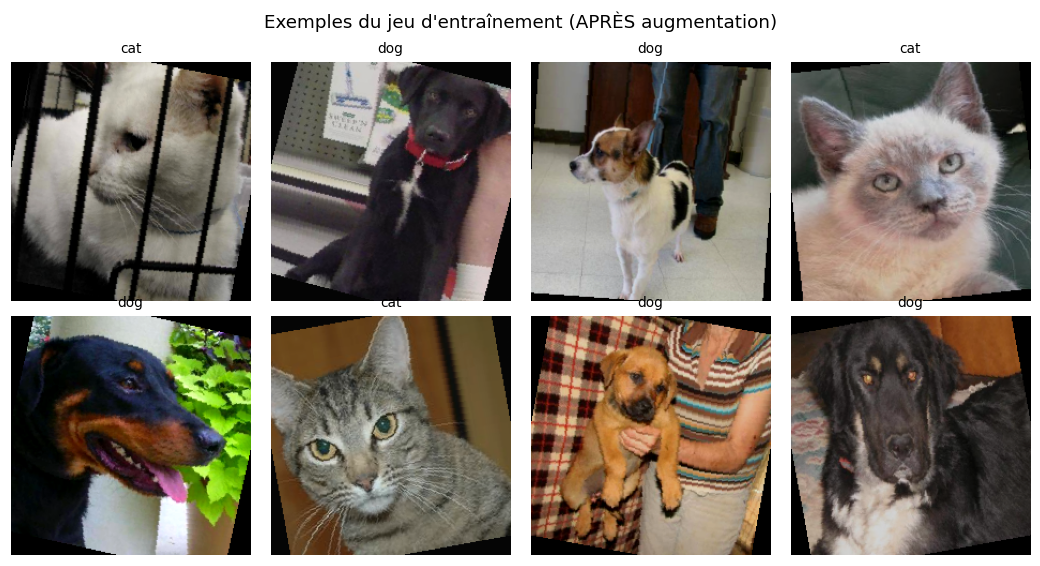

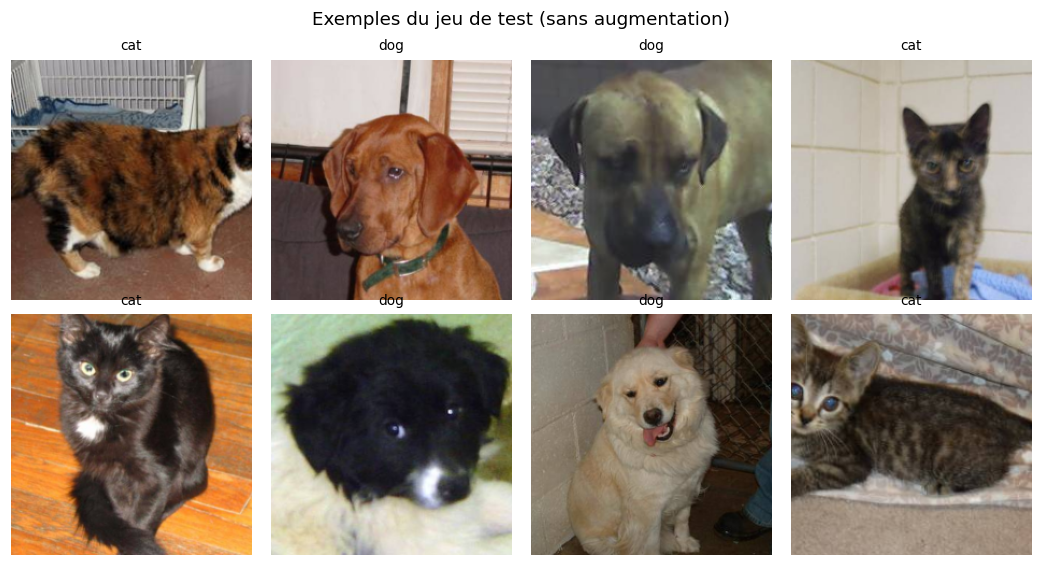

In [ ]:
def denormalize(t):
    # tenseur normalisé (C,H,W) -> tableau numpy (H,W,C) affichable
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


def show_samples(ds, title, n=8, seed=0):
    rng = np.random.RandomState(seed)
    idxs = rng.choice(len(ds), n, replace=False)
    fig, axes = plt.subplots(2, n // 2, figsize=(2.4 * n / 2, 5.2))
    for ax, i in zip(axes.ravel(), idxs):
        img, y = ds[int(i)]
        ax.imshow(denormalize(img)); ax.set_title(CLASS_NAMES[y], fontsize=9); ax.axis("off")
    fig.suptitle(title); fig.tight_layout()
    return fig

show_samples(train_ds, "Exemples du jeu d'entraînement (APRÈS augmentation)")
plt. show()
fig = show_samples(test_ds, "Exemples du jeu de test (sans augmentation)")
fig.savefig(FIGURES_DIR / "exemples_donnees.png", dpi=130, bbox_inches="tight")
plt.show()

### DataLoaders

In [ ]:
def make_loader(ds, shuffle, seed=None, batch_size=None, drop_last=False):
    g = torch.Generator()
    g.manual_seed(CFG["seed"] if seed is None else seed)
    nw = CFG["num_workers"]
    return DataLoader(ds, batch_size=batch_size or CFG["batch_size"], shuffle=shuffle,
                      drop_last=drop_last, num_workers=nw, pin_memory=(device.type == "cuda"),
                      worker_init_fn=seed_worker, generator=g, persistent_workers=(nw > 0))

val_loader  = make_loader(val_ds,  shuffle=False)
test_loader = make_loader(test_ds, shuffle=False)

xb, yb = next(iter(make_loader(train_ds, shuffle=True, drop_last=True)))
print("Batch train :", tuple(xb.shape), "| labels :", tuple(yb.shape), "| dtype :", xb.dtype)
print("Nb de batches -> train: %d | val: %d | test: %d" %
      (len(train_ds) // CFG["batch_size"], len(val_loader), len(test_loader)))

Batch train : (64, 3, 224, 224) | labels : (64,) | dtype : torch.float32
Nb de batches -> train: 281 | val: 71 | test: 40


## 2. Les Métriques

In [ ]:
def compute_metrics(y_true, y_pred):
    return dict(
        acc=float(accuracy_score(y_true, y_pred)),
        precision=float(precision_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0)),
        recall=float(recall_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0)),
        f1=float(f1_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0)),
    )


@torch.no_grad()
def evaluate(model, loader, criterion, return_outputs=False):
    # évalue `model` sur `loader` : loss + métriques (+ prédictions et probabilités si demandé)
    model.eval()
    loss_sum, n = torch.zeros((), device=device), 0
    ys, ps, probs = [], [], []
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=USE_AMP):
            logits = model(x)
        logits = logits.float()
        loss_sum += criterion(logits, y).detach() * x.size(0)
        n += x.size(0)
        ys.append(y.cpu()); ps.append(logits.argmax(1).cpu())
        if return_outputs:
            probs.append(F.softmax(logits, dim=1).cpu())
    y_true, y_pred = torch.cat(ys).numpy(), torch.cat(ps).numpy()
    out = dict(loss=float(loss_sum.item() / n), **compute_metrics(y_true, y_pred))
    if return_outputs:
        out.update(y_true=y_true, y_pred=y_pred, probs=torch.cat(probs).numpy())
    return out

### Boucle d'entraînement, sauvegarde du meilleur modèle, TensorBoard

In [ ]:
try:
    from torch.utils.tensorboard import SummaryWriter
except Exception:            # tensorboard non installé : on continue sans
    SummaryWriter = None


def set_train_mode(model):
    model.train()
    if getattr(model, "backbone_frozen", False):
        for name, child in model.named_children():
            if name != model.head_name:
                child.eval()


def train_one_epoch(model, loader, optimizer, criterion, scaler):
    set_train_mode(model)
    loss_sum, n = torch.zeros((), device=device), 0
    ys, ps = [], []
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=USE_AMP):
            logits = model(x)
            loss = criterion(logits.float(), y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        loss_sum += loss.detach() * x.size(0)
        n += x.size(0)
        ys.append(y.cpu()); ps.append(logits.detach().argmax(1).cpu())
    y_true, y_pred = torch.cat(ys).numpy(), torch.cat(ps).numpy()
    return dict(loss=float(loss_sum.item() / n), **compute_metrics(y_true, y_pred))


HIST_KEYS = ["train_loss", "train_acc", "train_precision", "train_recall",
             "val_loss", "val_acc", "val_precision", "val_recall", "val_f1", "lr", "epoch_time"]


def fit(name, model, optimizer, scheduler, train_loader, val_loader, epochs,
        save_ckpt=True, patience=None, writer=None, verbose=True):
    criterion = nn.CrossEntropyLoss()
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    history = {k: [] for k in HIST_KEYS}
    best = dict(epoch=0, val_acc=-1.0, val_loss=float("inf"), val_precision=0.0, val_recall=0.0)
    ckpt_path = CHECKPOINT_DIR / f"{name}_best.pt"
    t_start, bad_epochs = time.time(), 0

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
        va = evaluate(model, val_loader, criterion)
        lr_now = optimizer.param_groups[-1]["lr"]          # LR de la tête (dernier groupe)
        if scheduler is not None:
            scheduler.step()

        for k, v in [("train_loss", tr["loss"]), ("train_acc", tr["acc"]),
                     ("train_precision", tr["precision"]), ("train_recall", tr["recall"]),
                     ("val_loss", va["loss"]), ("val_acc", va["acc"]), ("val_precision", va["precision"]),
                     ("val_recall", va["recall"]), ("val_f1", va["f1"]), ("lr", lr_now),
                     ("epoch_time", time.time() - t0)]:
            history[k].append(float(v))

        improved = (va["acc"] > best["val_acc"]) or (va["acc"] == best["val_acc"] and va["loss"] < best["val_loss"])
        if improved:
            best = dict(epoch=epoch, val_acc=va["acc"], val_loss=va["loss"],
                        val_precision=va["precision"], val_recall=va["recall"])
            bad_epochs = 0
            if save_ckpt:
                torch.save({"model_state_dict": model.state_dict(), "run": name,
                            "epoch": epoch, "val_acc": va["acc"]}, ckpt_path)
        else:
            bad_epochs += 1

        if writer is not None:
            for split, m in (("train", tr), ("val", va)):
                for metric in ("loss", "acc", "precision", "recall"):
                    writer.add_scalar(f"{metric}/{split}", m[metric], epoch)
            writer.add_scalar("lr", lr_now, epoch)

        if verbose:
            print(f"[{name}] ép. {epoch:02d}/{epochs} | {time.time() - t0:5.1f}s | lr {lr_now:.2e} | "
                  f"train loss {tr['loss']:.4f} acc {tr['acc']:.4f} | "
                  f"val loss {va['loss']:.4f} acc {va['acc']:.4f} P {va['precision']:.3f} R {va['recall']:.3f}"
                  + ("  ← meilleur" if improved else ""))

        if patience is not None and bad_epochs >= patience:
            if verbose:
                print(f"Early stopping (pas d'amélioration depuis {patience} époques)")
            break

    if writer is not None:
        writer.flush()
    return history, best, time.time() - t_start

### Méthodes de corrections

* **Adam** : LR adaptatif par paramètre, converge vite, peu sensible au choix exact du LR.
* **SGD + momentum (0.9, Nesterov)** : plus sensible au LR, mais souvent très bon en généralisation quand bien réglé.
* **Scheduler** : `CosineAnnealingLR` par défaut (le LR décroît doucement jusqu'à ~0 sur la durée de l'entraînement :
  grands pas au début, ajustement fin à la fin). `StepLR` est aussi disponible via `CFG["scheduler"]`.
* **Fine-tuning** : LR *discriminatifs* — le backbone pré-entraîné reçoit un LR 10× plus petit (`backbone_lr_mult`)
  que la nouvelle tête, pour ne pas détruire les caractéristiques déjà apprises.

In [ ]:
def get_param_groups(model, lr, backbone_mult):
    if hasattr(model, "head_name") and not getattr(model, "backbone_frozen", False):
        head, backbone = [], []
        for n, p in model.named_parameters():
            (head if n.startswith(model.head_name + ".") else backbone).append(p)
        return [{"params": backbone, "lr": lr * backbone_mult},   # groupe 0 : backbone
                {"params": head, "lr": lr}]                       # groupe 1 : tête
    return [{"params": [p for p in model.parameters() if p.requires_grad], "lr": lr}]


def build_optimizer(model, name, lr, weight_decay=None):
    weight_decay = CFG["weight_decay"] if weight_decay is None else weight_decay
    groups = get_param_groups(model, lr, CFG["backbone_lr_mult"])
    if name == "adam":
        return torch.optim.Adam(groups, weight_decay=weight_decay)
    if name == "sgd":
        return torch.optim.SGD(groups, momentum=0.9, nesterov=True, weight_decay=weight_decay)
    raise ValueError(f"Optimiseur inconnu : {name}")


def build_scheduler(optimizer, name, epochs):
    if name == "cosine":
        return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    if name == "step":
        return torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(1, epochs // 3), gamma=0.1)
    return None


def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

## 3. Architectures

### Expérience A — CNN *from scratch* (4 blocs convolutionnels)

```
[Conv3×3 → BatchNorm → ReLU → MaxPool2] × 4     (32 → 64 → 128 → 256 canaux)
→ GlobalAvgPool → Dropout(0.5) → Linear(256→128) → ReLU → Dropout(0.5) → Linear(128→2)
```

### Expérience B — Transfert d'apprentissage (ResNet-18 pré-entraîné ImageNet)

Le backbone (poids ImageNet) est conservé ; la couche finale (1000 classes) est **remplacée** par une tête adaptée à 2 classes :

```
Dropout(0.3) → Linear(512→256) → BatchNorm1d → ReLU → Dropout(0.3) → Linear(256→2)
```

In [ ]:
def conv_block(in_c, out_c):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_c),          # BN après la conv, avant l'activation
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
    )


class SimpleCNN(nn.Module):
    # Expérience A : CNN simple, 4 blocs convolutionnels
    def __init__(self, n_classes=2, channels=(32, 64, 128, 256), dropout=0.5):
        super().__init__()
        blocks, in_c = [], 3
        for c in channels:
            blocks.append(conv_block(in_c, c))
            in_c = c
        self.features = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),         # Dropout dans la tête
            nn.Linear(in_c, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))


def make_head(in_features, p, n_classes=2, hidden=256):
    return nn.Sequential(
        nn.Dropout(p),
        nn.Linear(in_features, hidden),
        nn.BatchNorm1d(hidden),
        nn.ReLU(inplace=True),
        nn.Dropout(p),
        nn.Linear(hidden, n_classes),
    )


def build_transfer_model(arch="resnet18", freeze_backbone=False, dropout=0.3, pretrained=True):
    # Expérience B : backbone pré-entraîné + tête remplacée
    if arch == "resnet18":
        m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
        m.fc = make_head(m.fc.in_features, dropout)
        head_name = "fc"
    elif arch == "mobilenet_v2":
        m = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT if pretrained else None)
        m.classifier = make_head(m.classifier[1].in_features, dropout)
        head_name = "classifier"
    elif arch == "efficientnet_b0":
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT if pretrained else None)
        m.classifier = make_head(m.classifier[1].in_features, dropout)
        head_name = "classifier"
    else:
        raise ValueError(f"Architecture inconnue : {arch}")
    m.head_name, m.backbone_frozen = head_name, bool(freeze_backbone)
    if freeze_backbone:
        for n, p in m.named_parameters():
            if not n.startswith(head_name + "."):
                p.requires_grad = False
    return m


# Fabriques de modèles (`pretrained=False` au rechargement : inutile de re-télécharger les poids ImageNet)
BUILDERS = {
    "scratch":     lambda pretrained=None: SimpleCNN(dropout=CFG["dropout_scratch"]),
    "tl_finetune": lambda pretrained=CFG["pretrained"]: build_transfer_model(CFG["tl_arch"], False, CFG["dropout_tl"], pretrained),
    "tl_freeze":   lambda pretrained=CFG["pretrained"]: build_transfer_model(CFG["tl_arch"], True,  CFG["dropout_tl"], pretrained),
}

# ---- vérifications rapides (formes de sortie, nombre de paramètres) ----
dummy = torch.randn(4, 3, IMG, IMG)
rows = []
for key, build in BUILDERS.items():
    m = build().eval()
    with torch.no_grad():
        out = m(dummy)
    total, trainable = count_params(m)
    rows.append(dict(modèle=key, sortie=tuple(out.shape), params_totaux=f"{total:,}", params_entraînables=f"{trainable:,}"))
display(pd.DataFrame(rows))
print(BUILDERS["scratch"]())

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 214MB/s]


,modèle,sortie,params_totaux,params_entraînables
0,scratch,"(4, 2)","422,050","422,050"
1,tl_finetune,"(4, 2)","11,308,866","11,308,866"
2,tl_freeze,"(4, 2)","11,308,866","132,354"


SimpleCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)

## 4. Recherche du learning rate

In [ ]:
LR_GRIDS = {
    ("scratch", "adam"):     [1e-4, 1e-3, 1e-2],
    ("scratch", "sgd"):      [1e-3, 1e-2, 1e-1],
    ("tl_finetune", "adam"): [1e-4, 3e-4, 1e-3],
    ("tl_finetune", "sgd"):  [1e-3, 1e-2, 5e-2],
}
LR_CSV = RESULTS_DIR / "lr_search.csv"


def lr_search(builder, opt_name, lrs):
    rng = np.random.RandomState(CFG["seed"])
    sub_tr = Subset(train_ds, rng.choice(len(train_ds), min(CFG["lr_search_train_size"], len(train_ds)), replace=False))
    sub_va = Subset(val_ds,   rng.choice(len(val_ds),   min(CFG["lr_search_val_size"],   len(val_ds)),   replace=False))
    rows = []
    for lr in lrs:
        set_seed(CFG["seed"])
        model = BUILDERS[builder]().to(device)
        opt = build_optimizer(model, opt_name, lr)
        tr_loader = make_loader(sub_tr, shuffle=True, drop_last=True)
        va_loader = make_loader(sub_va, shuffle=False)
        hist, best, _ = fit(f"lrsearch_{builder}_{opt_name}_{lr:g}", model, opt, None, tr_loader, va_loader,
                            epochs=CFG["lr_search_epochs"], save_ckpt=False, verbose=False)
        rows.append(dict(builder=builder, optimizer=opt_name, lr=lr, best_val_acc=best["val_acc"],
                         final_val_loss=hist["val_loss"][-1], final_train_loss=hist["train_loss"][-1]))
        print(f"  {builder:12s} {opt_name:5s} lr={lr:<8g} -> val acc {best['val_acc']:.4f} | val loss {hist['val_loss'][-1]:.4f}")
        del model, opt, tr_loader, va_loader
    return pd.DataFrame(rows)


if CFG["reuse_existing"] and LR_CSV.exists():
    lr_df = pd.read_csv(LR_CSV)
    print("↩︎ Résultats de recherche de LR rechargés depuis", LR_CSV.name)
else:
    frames = []
    for (builder, opt_name), grid in LR_GRIDS.items():
        print(f"Recherche LR : {builder} / {opt_name}")
        frames.append(lr_search(builder, opt_name, grid))
    lr_df = pd.concat(frames, ignore_index=True)
    lr_df.to_csv(LR_CSV, index=False)

BEST_LR = {}
for (builder, opt_name), _ in LR_GRIDS.items():
    sub = lr_df[(lr_df.builder == builder) & (lr_df.optimizer == opt_name)]
    best_row = sub.sort_values(["best_val_acc", "final_val_loss"], ascending=[False, True]).iloc[0]
    BEST_LR[(builder, opt_name)] = float(best_row["lr"])

display(lr_df.round(4))
print("\nLR retenus :", {f"{b}/{o}": lr for (b, o), lr in BEST_LR.items()})

Recherche LR : scratch / adam
  scratch      adam  lr=0.0001   -> val acc 0.6240 | val loss 0.6366
  scratch      adam  lr=0.001    -> val acc 0.6340 | val loss 0.6318
  scratch      adam  lr=0.01     -> val acc 0.5920 | val loss 0.6794
Recherche LR : scratch / sgd
  scratch      sgd   lr=0.001    -> val acc 0.6060 | val loss 0.6510
  scratch      sgd   lr=0.01     -> val acc 0.6230 | val loss 0.6386
  scratch      sgd   lr=0.1      -> val acc 0.5990 | val loss 0.6752
Recherche LR : tl_finetune / adam
  tl_finetune  adam  lr=0.0001   -> val acc 0.9780 | val loss 0.0767
  tl_finetune  adam  lr=0.0003   -> val acc 0.9810 | val loss 0.0529
  tl_finetune  adam  lr=0.001    -> val acc 0.9810 | val loss 0.0705
Recherche LR : tl_finetune / sgd
  tl_finetune  sgd   lr=0.001    -> val acc 0.9630 | val loss 0.1270
  tl_finetune  sgd   lr=0.01     -> val acc 0.9790 | val loss 0.0551
  tl_finetune  sgd   lr=0.05     -> val acc 0.9800 | val loss 0.0532


,builder,optimizer,lr,best_val_acc,final_val_loss,final_train_loss
0,scratch,adam,0.0001,0.624,0.6366,0.6566
1,scratch,adam,0.0010,0.634,0.6318,0.6401
2,scratch,adam,0.0100,0.592,0.6794,0.6734
3,scratch,sgd,0.0010,0.606,0.6510,0.6754
4,scratch,sgd,0.0100,0.623,0.6386,0.6485
5,scratch,sgd,0.1000,0.599,0.6752,0.6784
6,tl_finetune,adam,0.0001,0.978,0.0767,0.0966
7,tl_finetune,adam,0.0003,0.981,0.0529,0.0353
8,tl_finetune,adam,0.0010,0.981,0.0705,0.0170
9,tl_finetune,sgd,0.0010,0.963,0.1270,0.1902



LR retenus : {'scratch/adam': 0.001, 'scratch/sgd': 0.01, 'tl_finetune/adam': 0.0003, 'tl_finetune/sgd': 0.05}


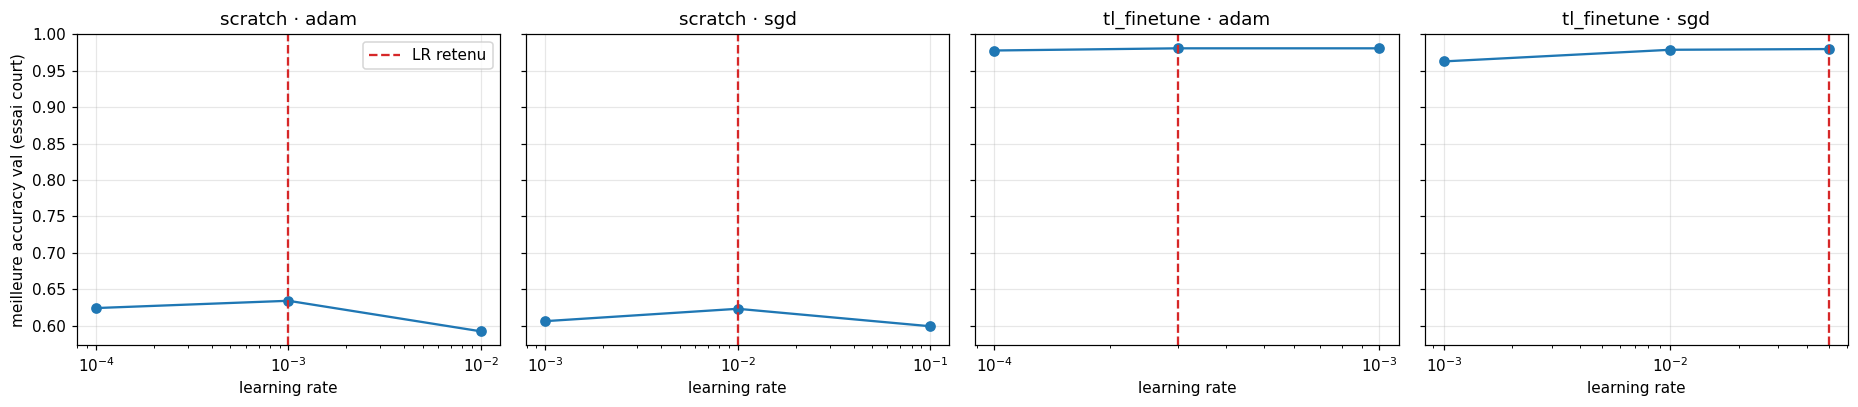

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(17, 3.8), sharey=True)
for ax, ((builder, opt_name), _) in zip(axes, LR_GRIDS.items()):
    sub = lr_df[(lr_df.builder == builder) & (lr_df.optimizer == opt_name)].sort_values("lr")
    ax.plot(sub["lr"], sub["best_val_acc"], "o-")
    ax.axvline(BEST_LR[(builder, opt_name)], color="tab:red", ls="--", label="LR retenu")
    ax.set_xscale("log"); ax.set_title(f"{builder} · {opt_name}"); ax.set_xlabel("learning rate")
axes[0].set_ylabel("meilleure accuracy val (essai court)"); axes[0].legend()
fig.tight_layout(); fig.savefig(FIGURES_DIR / "recherche_lr.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Entraînements

In [ ]:
EXPERIMENTS = [
    dict(key="A_adam", family="A", label="A · from scratch · Adam", builder="scratch",     optimizer="adam",
         lr_key=("scratch", "adam"),     epochs=CFG["epochs_scratch"], main=True),
    dict(key="A_sgd",  family="A", label="A · from scratch · SGD",  builder="scratch",     optimizer="sgd",
         lr_key=("scratch", "sgd"),      epochs=CFG["epochs_scratch"], main=True),
    dict(key="B_adam", family="B", label="B · transfert (fine-tuning) · Adam", builder="tl_finetune", optimizer="adam",
         lr_key=("tl_finetune", "adam"), epochs=CFG["epochs_tl"], main=True),
    dict(key="B_sgd",  family="B", label="B · transfert (fine-tuning) · SGD",  builder="tl_finetune", optimizer="sgd",
         lr_key=("tl_finetune", "sgd"),  epochs=CFG["epochs_tl"], main=True),
    dict(key="B_freeze_adam", family="B", label="B · transfert (backbone gelé) · Adam", builder="tl_freeze", optimizer="adam",
         lr_key=("tl_finetune", "adam"), epochs=CFG["epochs_tl"], main=False),
]
EXP_BY_KEY = {e["key"]: e for e in EXPERIMENTS}


def run_experiment(exp):
    key, lr = exp["key"], BEST_LR[exp["lr_key"]]
    hist_path = RESULTS_DIR / f"history_{key}.json"
    ckpt_path = CHECKPOINT_DIR / f"{key}_best.pt"
    if CFG["reuse_existing"] and hist_path.exists() and ckpt_path.exists():
        print(f"↩︎ {key} : run déjà terminé, historique rechargé ({hist_path.name})")
        return json.loads(hist_path.read_text())

    print(f"\n{'=' * 90}\n{exp['label']}  |  lr={lr:g}  |  {exp['epochs']} époques\n{'=' * 90}")
    set_seed(CFG["seed"])
    model = BUILDERS[exp["builder"]]().to(device)
    optimizer = build_optimizer(model, exp["optimizer"], lr)
    scheduler = build_scheduler(optimizer, CFG["scheduler"], exp["epochs"])
    train_loader = make_loader(train_ds, shuffle=True, drop_last=True)
    writer = SummaryWriter(RUNS_DIR / key, flush_secs=30) if SummaryWriter is not None else None

    history, best, elapsed = fit(key, model, optimizer, scheduler, train_loader, val_loader,
                                 epochs=exp["epochs"], patience=CFG["patience"], writer=writer)
    if writer is not None:
        writer.close()
    total, trainable = count_params(model)
    payload = dict(key=key, label=exp["label"], family=exp["family"], builder=exp["builder"],
                   optimizer=exp["optimizer"], lr=lr, epochs=exp["epochs"], history=history, best=best,
                   train_time_s=elapsed, params_total=total, params_trainable=trainable, ckpt=str(ckpt_path))
    hist_path.write_text(json.dumps(payload, indent=2))
    print(f"✔ {key} terminé en {elapsed / 60:.1f} min | meilleur epoch {best['epoch']} | val acc {best['val_acc']:.4f}")
    del model, optimizer, train_loader
    return payload

In [ ]:
RESULTS = {}
for exp in EXPERIMENTS:
    RESULTS[exp["key"]] = run_experiment(exp)


A · from scratch · Adam  |  lr=0.001  |  15 époques
[A_adam] ép. 01/15 | 123.9s | lr 1.00e-03 | train loss 0.6482 acc 0.6167 | val loss 0.5957 acc 0.6843 P 0.717 R 0.609  ← meilleur
[A_adam] ép. 02/15 | 122.8s | lr 9.89e-04 | train loss 0.6064 acc 0.6700 | val loss 0.5701 acc 0.7010 P 0.854 R 0.485  ← meilleur
[A_adam] ép. 03/15 | 123.0s | lr 9.57e-04 | train loss 0.5770 acc 0.7011 | val loss 0.5245 acc 0.7443 P 0.832 R 0.612  ← meilleur
[A_adam] ép. 04/15 | 125.6s | lr 9.05e-04 | train loss 0.5472 acc 0.7291 | val loss 0.5261 acc 0.7449 P 0.796 R 0.658  ← meilleur
[A_adam] ép. 05/15 | 123.9s | lr 8.35e-04 | train loss 0.5249 acc 0.7462 | val loss 0.6939 acc 0.6303 P 0.935 R 0.280
[A_adam] ép. 06/15 | 122.3s | lr 7.50e-04 | train loss 0.5050 acc 0.7591 | val loss 0.4827 acc 0.7641 P 0.830 R 0.664  ← meilleur
[A_adam] ép. 07/15 | 122.6s | lr 6.55e-04 | train loss 0.4899 acc 0.7705 | val loss 0.4232 acc 0.8163 P 0.826 R 0.801  ← meilleur
[A_adam] ép. 08/15 | 121.1s | lr 5.52e-04 | train

## 6. Courbes et comparaison des deux approches

Convention : **couleur = optimiseur** (bleu = Adam, orange = SGD) ; **style = approche**
(pointillés longs = A from scratch, trait plein = B fine-tuning, pointillés courts = B backbone gelé).

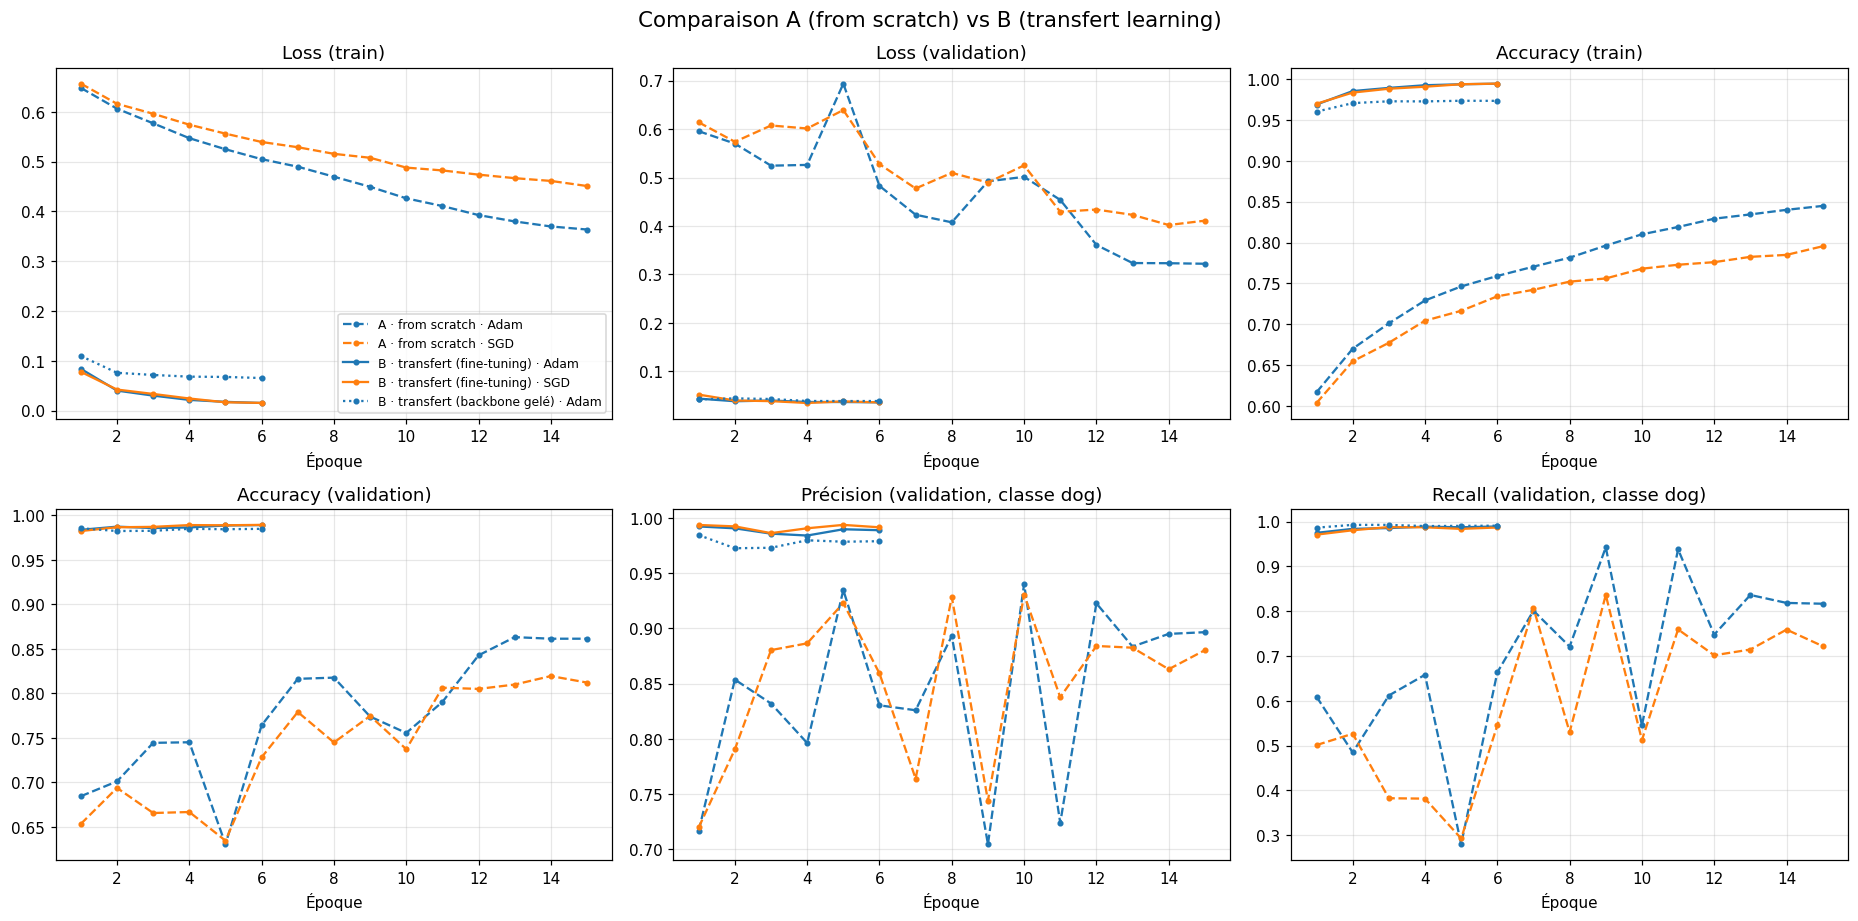

In [ ]:
def style_of(exp):
    color = {"adam": "tab:blue", "sgd": "tab:orange"}[exp["optimizer"]]
    ls = {"scratch": "--", "tl_finetune": "-", "tl_freeze": ":"}[exp["builder"]]
    return color, ls


def plot_comparison(save_name="comparaison_courbes.png"):
    panels = [("train_loss", "Loss (train)"), ("val_loss", "Loss (validation)"),
              ("train_acc", "Accuracy (train)"), ("val_acc", "Accuracy (validation)"),
              ("val_precision", "Précision (validation, classe dog)"), ("val_recall", "Recall (validation, classe dog)")]
    fig, axes = plt.subplots(2, 3, figsize=(17, 8.5))
    for ax, (k, title) in zip(axes.ravel(), panels):
        for exp in EXPERIMENTS:
            h = RESULTS[exp["key"]]["history"]
            c, ls = style_of(exp)
            ax.plot(range(1, len(h[k]) + 1), h[k], color=c, linestyle=ls, marker="o", ms=3, label=exp["label"])
        ax.set_title(title); ax.set_xlabel("Époque"); ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    axes[0, 0].legend(fontsize=8)
    fig.suptitle("Comparaison A (from scratch) vs B (transfert learning)", fontsize=14)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / save_name, dpi=150, bbox_inches="tight")
    plt.show()


plot_comparison()

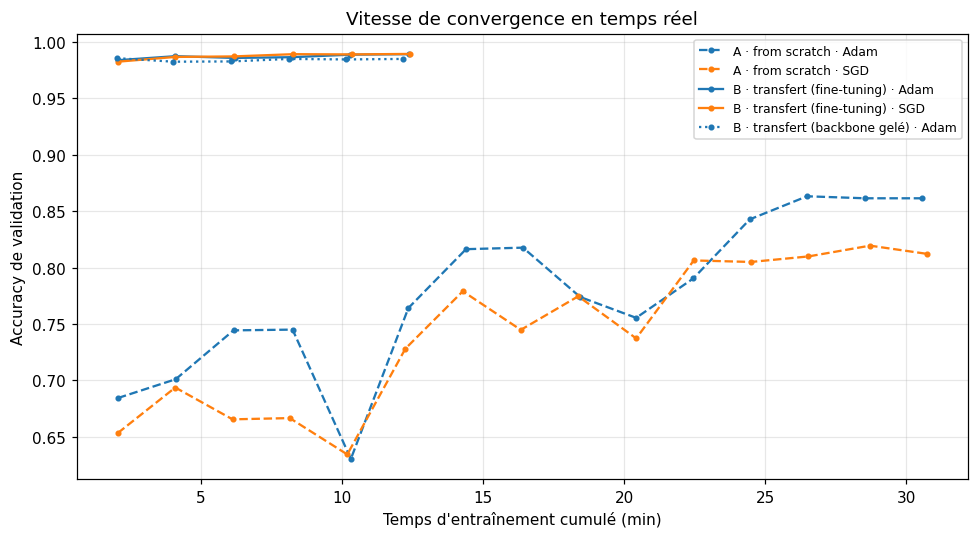

In [ ]:
# Convergence en TEMPS réel : accuracy de validation en fonction du temps d'entraînement cumulé
fig, ax = plt.subplots(figsize=(9, 5))
for exp in EXPERIMENTS:
    h = RESULTS[exp["key"]]["history"]
    c, ls = style_of(exp)
    ax.plot(np.cumsum(h["epoch_time"]) / 60, h["val_acc"], color=c, linestyle=ls, marker="o", ms=3, label=exp["label"])
ax.set_xlabel("Temps d'entraînement cumulé (min)"); ax.set_ylabel("Accuracy de validation")
ax.set_title("Vitesse de convergence en temps réel"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIGURES_DIR / "convergence_temps.png", dpi=150, bbox_inches="tight")
plt.show()

### Train vs validation, run par run

Permet de repérer le **sur-apprentissage** (écart croissant entre les courbes train et val) et l'effet de la régularisation.

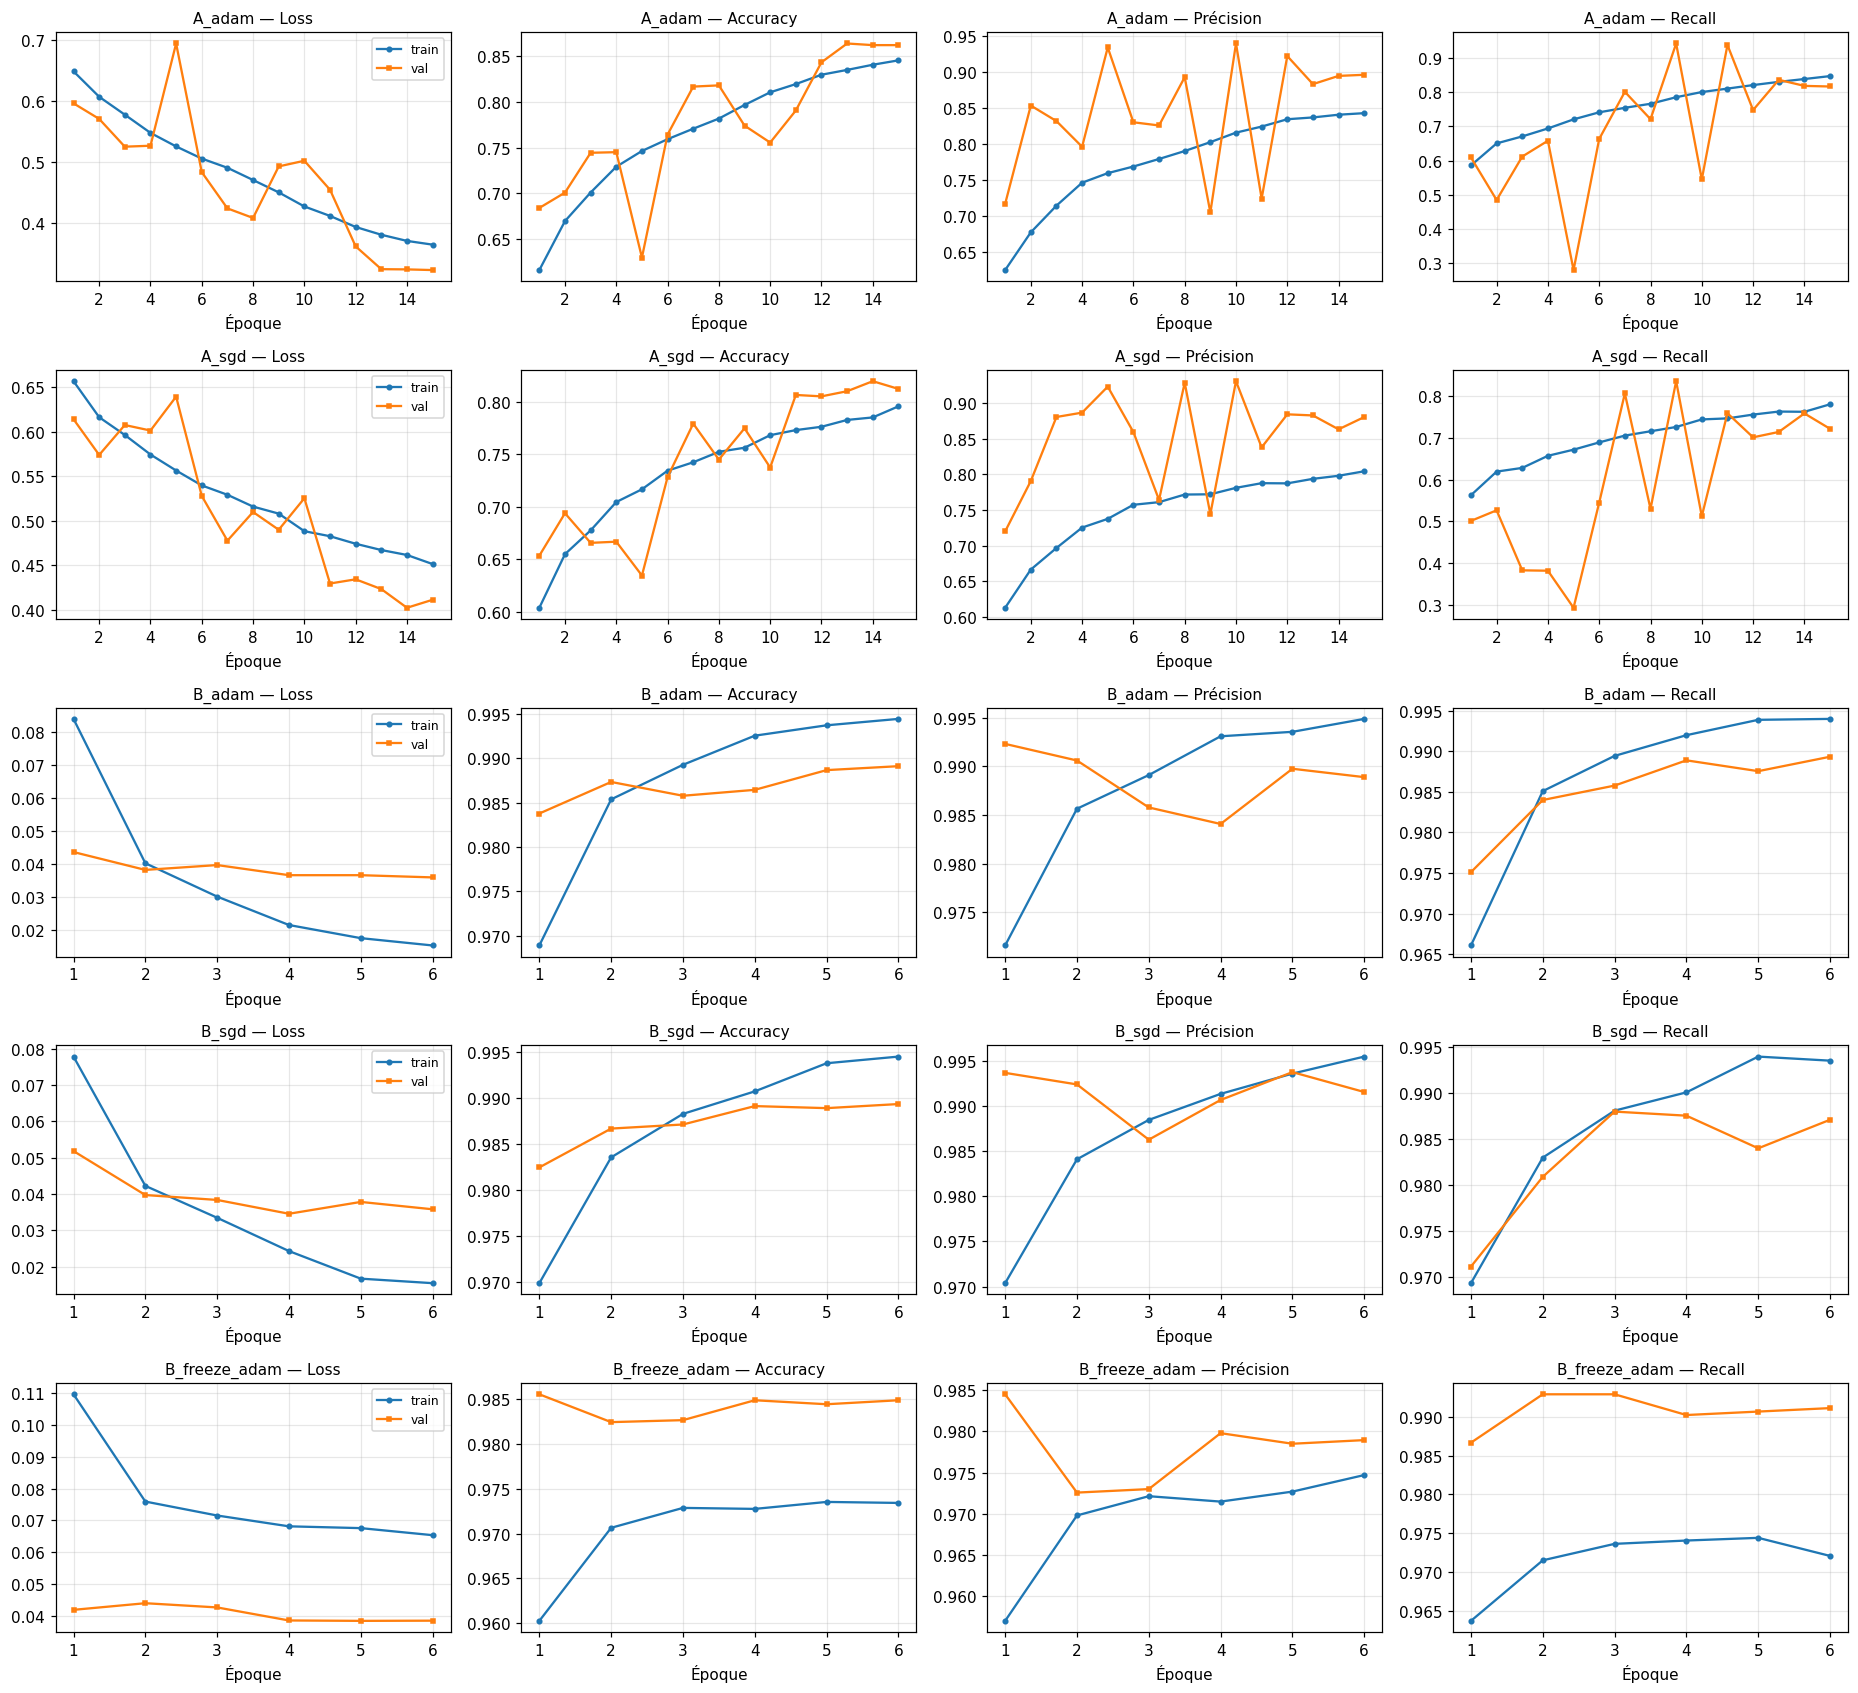

In [ ]:
def plot_train_val(save_name="train_vs_val.png"):
    metrics = [("loss", "Loss"), ("acc", "Accuracy"), ("precision", "Précision"), ("recall", "Recall")]
    fig, axes = plt.subplots(len(EXPERIMENTS), 4, figsize=(17, 3.1 * len(EXPERIMENTS)), squeeze=False)
    for r, exp in enumerate(EXPERIMENTS):
        h = RESULTS[exp["key"]]["history"]
        ep = range(1, len(h["train_loss"]) + 1)
        for c, (m, title) in enumerate(metrics):
            ax = axes[r, c]
            ax.plot(ep, h[f"train_{m}"], "o-", ms=3, label="train")
            ax.plot(ep, h[f"val_{m}"], "s-", ms=3, label="val")
            ax.set_title(f"{exp['key']} — {title}", fontsize=10); ax.set_xlabel("Époque")
            ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        axes[r, 0].legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / save_name, dpi=140, bbox_inches="tight")
    plt.show()


plot_train_val()

## 7. Évaluation finale sur le test — après **rechargement** du meilleur model

In [ ]:
def load_best_model(exp_key, ckpt_path=None):
    exp = EXP_BY_KEY[exp_key]
    path = Path(ckpt_path) if ckpt_path else CHECKPOINT_DIR / f"{exp_key}_best.pt"
    model = BUILDERS[exp["builder"]](pretrained=False).to(device)
    ckpt = torch.load(path, map_location=device, weights_only=True)
    model.load_state_dict(ckpt["model_state_dict"])
    return model.eval(), ckpt


criterion = nn.CrossEntropyLoss()
TEST = {}
for exp in EXPERIMENTS:
    key = exp["key"]
    model, ckpt = load_best_model(key)
    val_check = evaluate(model, val_loader, criterion)               # contrôle du rechargement
    TEST[key] = evaluate(model, test_loader, criterion, return_outputs=True)
    TEST[key]["ckpt_epoch"] = ckpt["epoch"]
    print(f"{key:14s} | epoch rechargé {ckpt['epoch']:2d} | val acc enregistrée {ckpt['val_acc']:.4f} "
          f"vs rechargée {val_check['acc']:.4f} | TEST acc {TEST[key]['acc']:.4f}")
    del model

A_adam         | epoch rechargé 13 | val acc enregistrée 0.8631 vs rechargée 0.8631 | TEST acc 0.8476
A_sgd          | epoch rechargé 14 | val acc enregistrée 0.8194 vs rechargée 0.8194 | TEST acc 0.8112
B_adam         | epoch rechargé  6 | val acc enregistrée 0.9891 vs rechargée 0.9891 | TEST acc 0.9872
B_sgd          | epoch rechargé  6 | val acc enregistrée 0.9893 vs rechargée 0.9893 | TEST acc 0.9844
B_freeze_adam  | epoch rechargé  1 | val acc enregistrée 0.9856 vs rechargée 0.9856 | TEST acc 0.9848


In [ ]:
CONV_THR = 0.90   # seuil pour mesurer la vitesse de convergence


def epochs_to_reach(hist, thr=CONV_THR):
    for i, a in enumerate(hist["val_acc"], start=1):
        if a >= thr:
            return i
    return np.nan


rows = []
for exp in EXPERIMENTS:
    r, t = RESULTS[exp["key"]], TEST[exp["key"]]
    rows.append({
        "run": exp["key"], "approche": exp["family"], "optimiseur": exp["optimizer"], "lr": r["lr"],
        "époques": len(r["history"]["val_acc"]), "meilleur epoch": r["best"]["epoch"],
        "val acc": r["best"]["val_acc"],
        "test loss": t["loss"], "test acc": t["acc"], "test précision": t["precision"],
        "test recall": t["recall"], "test F1": t["f1"],
        f"époques pour val≥{CONV_THR:.0%}": epochs_to_reach(r["history"]),
        "val acc à l'époque 1": r["history"]["val_acc"][0],
        "temps (min)": r["train_time_s"] / 60,
        "params entraînables": r["params_trainable"],
    })
results_df = pd.DataFrame(rows).set_index("run")
display(results_df.round(4))

# Meilleur modèle de chaque approche : choisi sur la VALIDATION (jamais sur le test)
BEST = {}
for fam in ("A", "B"):
    cands = [e["key"] for e in EXPERIMENTS if e["family"] == fam and e["main"]]
    BEST[fam] = max(cands, key=lambda k: (RESULTS[k]["best"]["val_acc"], -RESULTS[k]["best"]["val_loss"]))
print("\nMeilleur run A :", BEST["A"], "| meilleur run B :", BEST["B"], "(sélection sur la validation)")

,approche,optimiseur,lr,époques,meilleur epoch,val acc,test loss,test acc,test précision,test recall,test F1,époques pour val≥90%,val acc à l'époque 1,temps (min),params entraînables
run,,,,,,,,,,,,,,,
A_adam,A,adam,0.0010,15,13,0.8631,0.3544,0.8476,0.8717,0.8152,0.8425,NaN,0.6843,30.5613,422050
A_sgd,A,sgd,0.0100,15,14,0.8194,0.4325,0.8112,0.8524,0.7528,0.7995,NaN,0.6532,30.7525,422050
B_adam,B,adam,0.0003,6,6,0.9891,0.0292,0.9872,0.9880,0.9864,0.9872,1.0,0.9838,12.3958,11308866
B_sgd,B,sgd,0.0500,6,6,0.9893,0.0329,0.9844,0.9856,0.9832,0.9844,1.0,0.9824,12.4234,11308866
B_freeze_adam,B,adam,0.0003,6,1,0.9856,0.0422,0.9848,0.9848,0.9848,0.9848,1.0,0.9856,12.1844,132354



Meilleur run A : A_adam | meilleur run B : B_sgd (sélection sur la validation)


### Matrices de confusion (test)

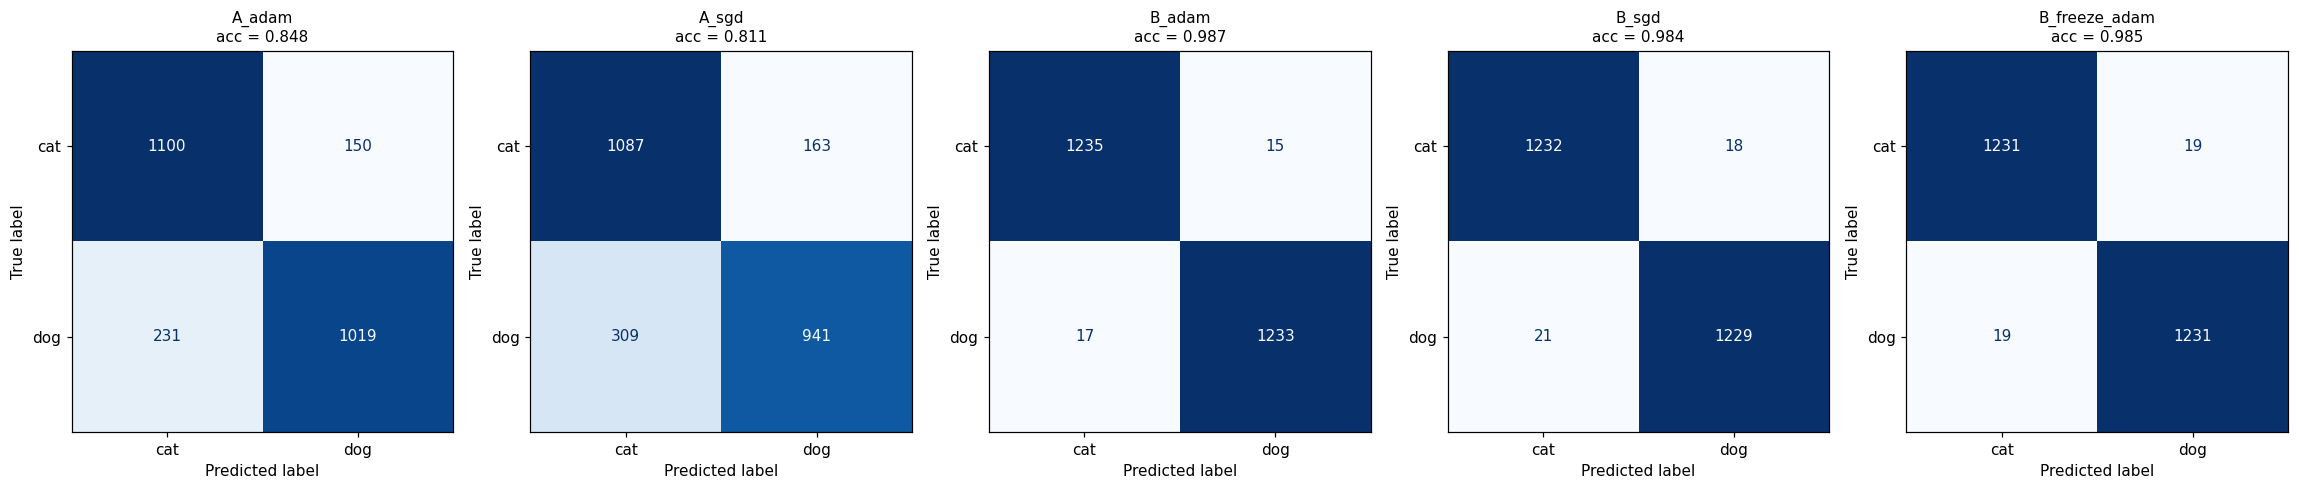


=== Rapport de classification — meilleur run A (A_adam) sur le TEST ===
              precision    recall  f1-score   support

         cat     0.8264    0.8800    0.8524      1250
         dog     0.8717    0.8152    0.8425      1250

    accuracy                         0.8476      2500
   macro avg     0.8491    0.8476    0.8474      2500
weighted avg     0.8491    0.8476    0.8474      2500


=== Rapport de classification — meilleur run B (B_sgd) sur le TEST ===
              precision    recall  f1-score   support

         cat     0.9832    0.9856    0.9844      1250
         dog     0.9856    0.9832    0.9844      1250

    accuracy                         0.9844      2500
   macro avg     0.9844    0.9844    0.9844      2500
weighted avg     0.9844    0.9844    0.9844      2500



In [ ]:
fig, axes = plt.subplots(1, len(EXPERIMENTS), figsize=(4.2 * len(EXPERIMENTS), 4.2))
for ax, exp in zip(axes, EXPERIMENTS):
    t = TEST[exp["key"]]
    ConfusionMatrixDisplay.from_predictions(t["y_true"], t["y_pred"], display_labels=CLASS_NAMES,
                                            ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{exp['key']}\nacc = {t['acc']:.3f}", fontsize=10); ax.grid(False)
fig.tight_layout(); fig.savefig(FIGURES_DIR / "matrices_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

for fam in ("A", "B"):
    k = BEST[fam]
    print(f"\n=== Rapport de classification — meilleur run {fam} ({k}) sur le TEST ===")
    print(classification_report(TEST[k]["y_true"], TEST[k]["y_pred"], target_names=CLASS_NAMES, digits=4))

## 8. Erreurs typiques

On affiche, pour le meilleur modèle de chaque approche, les images de test mal classées **avec la plus forte confiance**
(les erreurs les plus « surprenantes »), ainsi que le type d'erreur dominant.

A_adam : 381 erreurs sur 2500 images (cat→dog : 150 | dog→cat : 231)


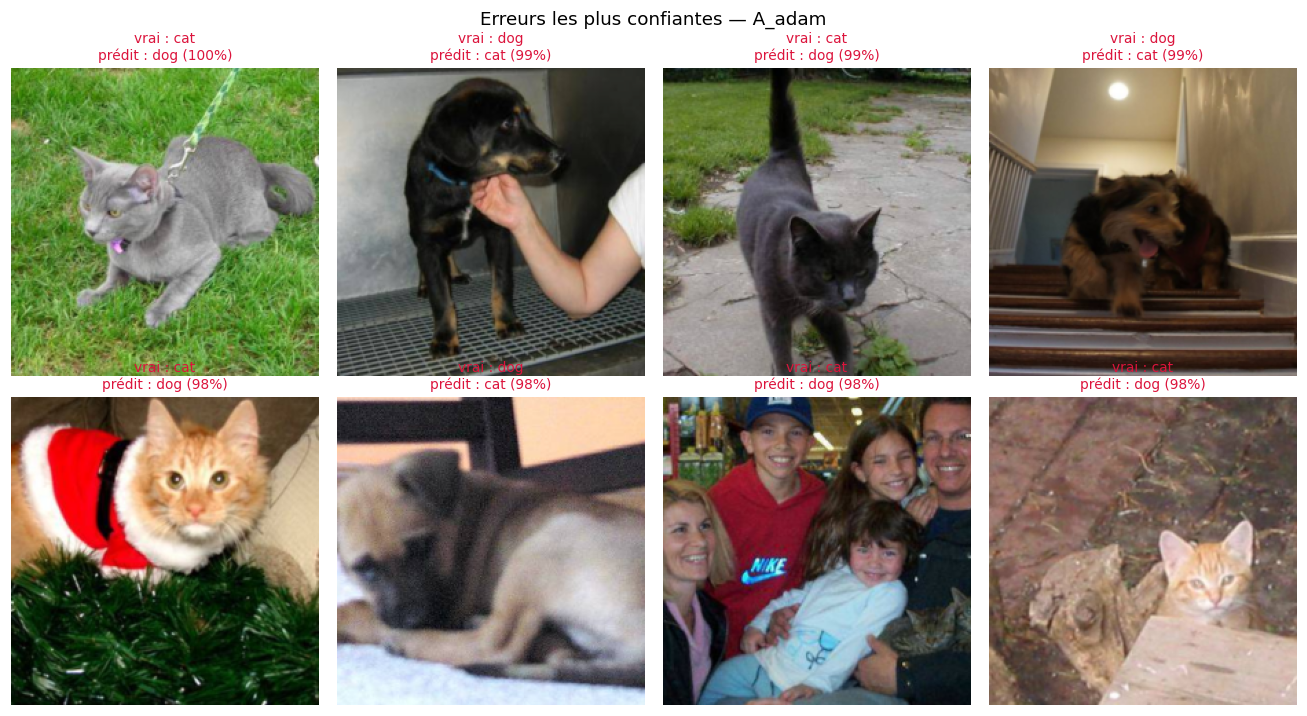

B_sgd : 39 erreurs sur 2500 images (cat→dog : 18 | dog→cat : 21)


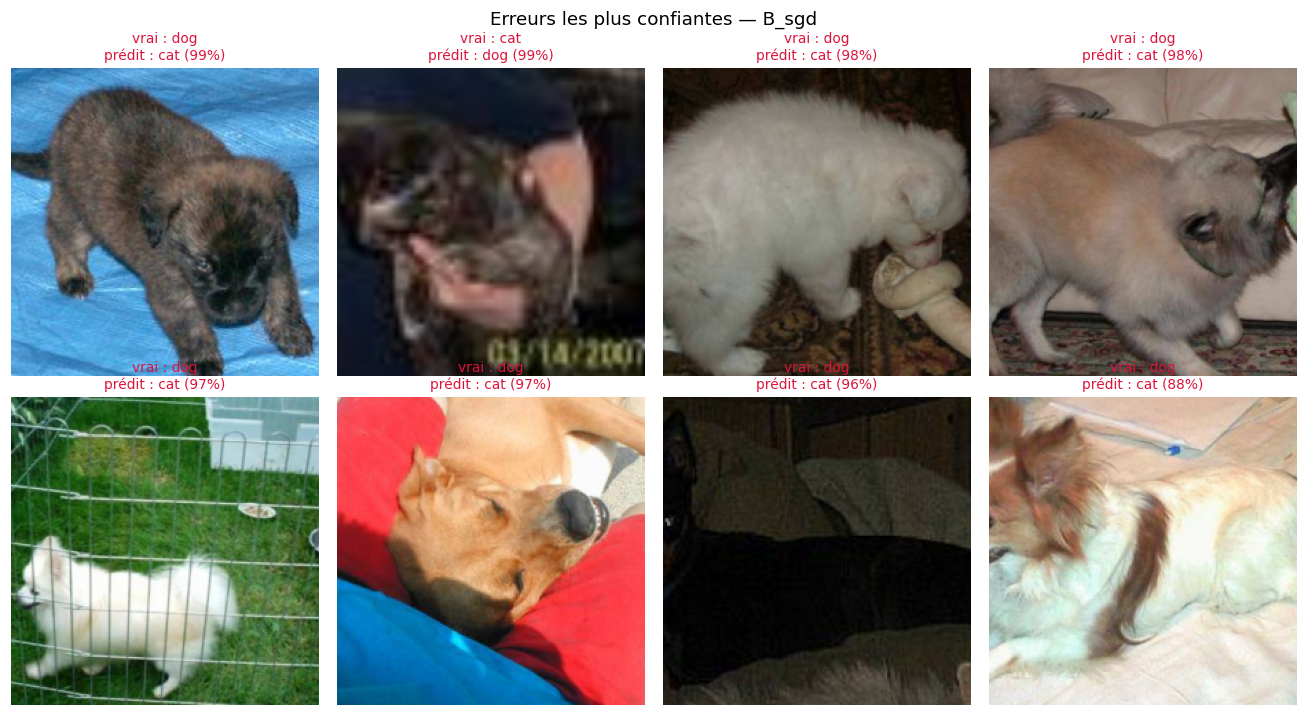

In [ ]:
test_view_ds = make_test_dataset(eval_tf)      # même ordre que test_loader (shuffle=False)


def show_errors(exp_key, n=8, save_name=None):
    t = TEST[exp_key]
    wrong = np.where(t["y_true"] != t["y_pred"])[0]
    conf = t["probs"][wrong, t["y_pred"][wrong]]
    order = wrong[np.argsort(-conf)][:n]
    c2d = int(((t["y_true"] == 0) & (t["y_pred"] == 1)).sum())
    d2c = int(((t["y_true"] == 1) & (t["y_pred"] == 0)).sum())
    print(f"{exp_key} : {len(wrong)} erreurs sur {len(t['y_true'])} images "
          f"(cat→dog : {c2d} | dog→cat : {d2c})")
    if len(order) == 0:
        return
    cols = 4
    fig, axes = plt.subplots(int(np.ceil(len(order) / cols)), cols, figsize=(3 * cols, 3.3 * int(np.ceil(len(order) / cols))))
    for ax in np.atleast_1d(axes).ravel():
        ax.axis("off")
    for ax, i in zip(np.atleast_1d(axes).ravel(), order):
        img, _ = test_view_ds[int(i)]
        ax.imshow(denormalize(img))
        p = t["probs"][i, t["y_pred"][i]]
        ax.set_title(f"vrai : {CLASS_NAMES[t['y_true'][i]]}\nprédit : {CLASS_NAMES[t['y_pred'][i]]} ({p:.0%})",
                     fontsize=9, color="crimson")
    fig.suptitle(f"Erreurs les plus confiantes — {exp_key}"); fig.tight_layout()
    if save_name:
        fig.savefig(FIGURES_DIR / save_name, dpi=140, bbox_inches="tight")
    plt.show()


show_errors(BEST["A"], save_name="erreurs_A.png")
show_errors(BEST["B"], save_name="erreurs_B.png")

## 9. Robustesse

,acc A (A_adam),acc B (B_sgd),chute A (pts),chute B (pts)
perturbation,,,,
Original,0.8476,0.9844,0.00,0.00
Flou gaussien,0.5204,0.8288,32.72,15.56
Bruit gaussien (σ=0.15),0.5024,0.8608,34.52,12.36
Faible luminosité (×0.4),0.7256,0.9804,12.20,0.40
Rotation 30°,0.7772,0.9776,7.04,0.68
Basse résolution (32 px),0.5156,0.7908,33.20,19.36


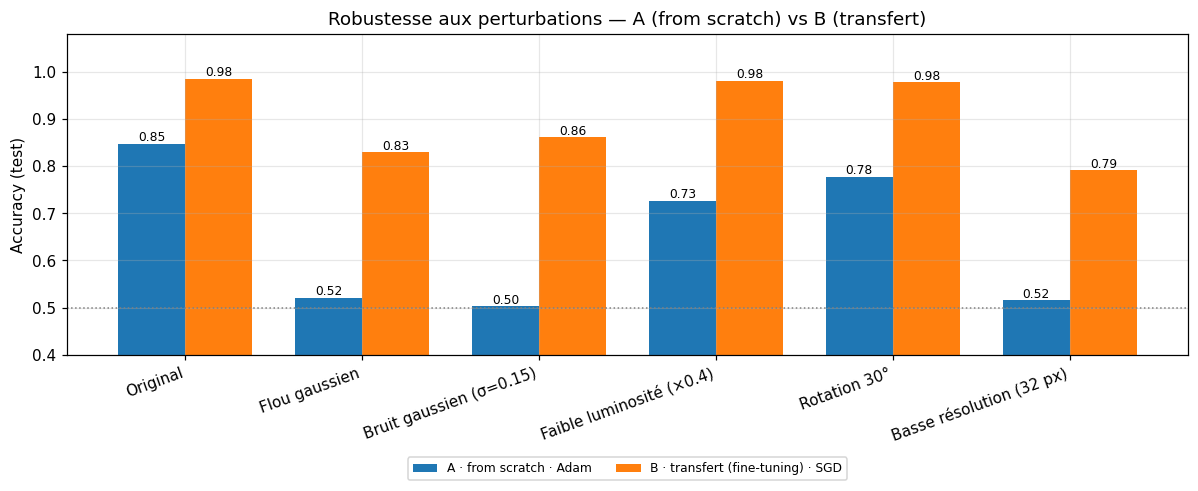

In [ ]:
def p_blur(x):    return TF.gaussian_blur(x, kernel_size=[15, 15], sigma=[4.0, 4.0])
def p_noise(x):   return (x + 0.15 * torch.randn_like(x)).clamp(0, 1)
def p_dark(x):    return TF.adjust_brightness(x, 0.4)
def p_rotate(x):  return TF.rotate(x, 30)
def p_lowres(x):  return TF.resize(TF.resize(x, [32, 32], antialias=True), [IMG, IMG], antialias=True)
def p_none(x):    return x

PERTURBATIONS = {
    "Original": p_none,
    "Flou gaussien": p_blur,
    "Bruit gaussien (σ=0.15)": p_noise,
    "Faible luminosité (×0.4)": p_dark,
    "Rotation 30°": p_rotate,
    "Basse résolution (32 px)": p_lowres,
}


def eval_perturbation(model, fn):
    tf = transforms.Compose([transforms.Resize(RESIZE_SIZE), transforms.CenterCrop(IMG), transforms.ToTensor(),
                             transforms.Lambda(fn), normalize])
    loader = make_loader(make_test_dataset(tf), shuffle=False)
    set_seed(CFG["seed"])                        # bruit reproductible
    return evaluate(model, loader, criterion)


rob_rows = []
for fam in ("A", "B"):
    model, _ = load_best_model(BEST[fam])
    for name, fn in PERTURBATIONS.items():
        m = eval_perturbation(model, fn)
        rob_rows.append(dict(perturbation=name, approche=fam, run=BEST[fam], acc=m["acc"], f1=m["f1"]))
    del model
rob_df = pd.DataFrame(rob_rows)
rob_acc = rob_df.pivot(index="perturbation", columns="approche", values="acc").loc[list(PERTURBATIONS)]
rob_acc.columns = [f"acc {c} ({BEST[c]})" for c in rob_acc.columns]
for c in ("A", "B"):
    rob_acc[f"chute {c} (pts)"] = (rob_acc.iloc[0][f"acc {c} ({BEST[c]})"] - rob_acc[f"acc {c} ({BEST[c]})"]) * 100
display(rob_acc.round(4))

fig, ax = plt.subplots(figsize=(11, 4.8))
w, x = 0.38, np.arange(len(PERTURBATIONS))
for j, fam in enumerate(("A", "B")):
    vals = rob_acc[f"acc {fam} ({BEST[fam]})"].values
    bars = ax.bar(x + (j - 0.5) * w, vals, w, label=EXP_BY_KEY[BEST[fam]]["label"])
    ax.bar_label(bars, fmt="%.2f", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(list(PERTURBATIONS), rotation=20, ha="right")
ax.set_ylim(0.4, 1.08); ax.set_ylabel("Accuracy (test)"); ax.axhline(0.5, color="gray", ls=":", lw=1)
ax.set_title("Robustesse aux perturbations — A (from scratch) vs B (transfert)")
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=2)
fig.tight_layout(); fig.savefig(FIGURES_DIR / "robustesse.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Synthèse chiffrée et analyse

In [ ]:
a, b = BEST["A"], BEST["B"]
ra, rb, ta, tb = RESULTS[a], RESULTS[b], TEST[a], TEST[b]
ea, eb = epochs_to_reach(ra["history"]), epochs_to_reach(rb["history"])
drop_a = rob_acc["chute A (pts)"].iloc[1:].mean()
drop_b = rob_acc["chute B (pts)"].iloc[1:].mean()

print(f"• Performance (test)  : A ({a}) acc = {ta['acc']:.4f} | B ({b}) acc = {tb['acc']:.4f} "
      f"→ écart = {100 * (tb['acc'] - ta['acc']):+.2f} points en faveur de {'B' if tb['acc'] >= ta['acc'] else 'A'}")
print(f"• Précision / recall  : A P={ta['precision']:.3f} R={ta['recall']:.3f} | B P={tb['precision']:.3f} R={tb['recall']:.3f}")
print(f"• Convergence         : accuracy val après l'époque 1 → A {ra['history']['val_acc'][0]:.3f} | B {rb['history']['val_acc'][0]:.3f}")
print(f"                        époques pour atteindre val ≥ {CONV_THR:.0%} → A {ea} | B {eb}  (NaN = jamais atteint)")
print(f"• Coût                : temps total A = {ra['train_time_s'] / 60:.1f} min ({len(ra['history']['val_acc'])} ép.) | "
      f"B = {rb['train_time_s'] / 60:.1f} min ({len(rb['history']['val_acc'])} ép.)")
print(f"• Paramètres          : A = {ra['params_trainable']:,} | B = {rb['params_trainable']:,} entraînables")
print(f"• Robustesse          : chute moyenne d'accuracy sous perturbation → A {drop_a:.1f} pts | B {drop_b:.1f} pts")
gap_a = ra["history"]["train_acc"][ra["best"]["epoch"] - 1] - ra["best"]["val_acc"]
gap_b = rb["history"]["train_acc"][rb["best"]["epoch"] - 1] - rb["best"]["val_acc"]
print(f"• Écart train − val   : A {100 * gap_a:+.1f} pts | B {100 * gap_b:+.1f} pts (au meilleur epoch ; négatif = train pénalisé par augmentation + Dropout)")

for fam_opt in (("A_adam", "A_sgd"), ("B_adam", "B_sgd")):
    x, y = fam_opt
    print(f"• Optimiseur ({x[0]})     : Adam val {RESULTS[x]['best']['val_acc']:.4f} vs SGD val {RESULTS[y]['best']['val_acc']:.4f}")
print(f"• Ablation (B)        : fine-tuning val {RESULTS['B_adam']['best']['val_acc']:.4f} vs backbone gelé val {RESULTS['B_freeze_adam']['best']['val_acc']:.4f}")

• Performance (test)  : A (A_adam) acc = 0.8476 | B (B_sgd) acc = 0.9844 → écart = +13.68 points en faveur de B
• Précision / recall  : A P=0.872 R=0.815 | B P=0.986 R=0.983
• Convergence         : accuracy val après l'époque 1 → A 0.684 | B 0.982
                        époques pour atteindre val ≥ 90% → A nan | B 1  (NaN = jamais atteint)
• Coût                : temps total A = 30.6 min (15 ép.) | B = 12.4 min (6 ép.)
• Paramètres          : A = 422,050 | B = 11,308,866 entraînables
• Robustesse          : chute moyenne d'accuracy sous perturbation → A 23.9 pts | B 9.7 pts
• Écart train − val   : A -2.9 pts | B +0.5 pts (au meilleur epoch ; négatif = train pénalisé par augmentation + Dropout)
• Optimiseur (A)     : Adam val 0.8631 vs SGD val 0.8194
• Optimiseur (B)     : Adam val 0.9891 vs SGD val 0.9893
• Ablation (B)        : fine-tuning val 0.9891 vs backbone gelé val 0.9856


### Analyse (à rédiger avec **vos** chiffres — ~3 paragraphes)

> Les chiffres ci-dessus sont produits par votre exécution ; ne recopiez pas de valeurs d'un autre run.
> Trame suggérée pour le README :

**1. Convergence.** Comparer la valeur de l'accuracy de validation dès l'époque 1 pour A et B, le nombre d'époques (et de minutes)
nécessaires pour dépasser le seuil de 90 %, et la forme des courbes de loss. *Pourquoi ?* Le backbone de B a déjà appris des
caractéristiques visuelles générales (contours, textures, parties d'animaux) sur ImageNet, qui contient de nombreuses classes de chats et chiens ;
A doit tout apprendre depuis des poids aléatoires.

**2. Performance et optimisation.** Commenter les métriques de test (accuracy, précision, recall, F1), les matrices de confusion
(quel type d'erreur domine : cat→dog ou dog→cat ?), et les erreurs typiques affichées en section 8 (posture, arrière-plan, plusieurs animaux, image sombre…).
Comparer Adam vs SGD (sensibilité au LR observée dans la recherche de la section 4), l'effet du scheduler, et l'ablation *backbone gelé vs fine-tuning*.
Commenter l'écart train/val : la régularisation (BN + Dropout + augmentation) est-elle suffisante pour A ? pour B ?

**3. Robustesse.** Commenter le tableau de la section 9 : quelles perturbations dégradent le plus chaque modèle ? Le modèle B (représentations
apprises sur des millions d'images variées) chute-t-il moins que A ? Nuancer : un seul run par configuration, donc des écarts de l'ordre de
±1 point ne sont pas significatifs.

### Sauvegarde des tableaux et de l'environnement

Les tableaux (Markdown/CSV) et figures sont enregistrés dans `results/` et `figures/` : **légers, versionnables**, et directement
réutilisables dans le `README.md`. Les checkpoints `.pt`, les logs TensorBoard et les données restent **hors GitHub**.

In [ ]:
def df_to_md(df, floatfmt=4):
    df = df.reset_index() if df.index.name else df
    cols = list(df.columns)
    out = ["| " + " | ".join(map(str, cols)) + " |", "|" + "|".join(["---"] * len(cols)) + "|"]
    for _, row in df.iterrows():
        cells = []
        for v in row:
            cells.append(f"{v:.{floatfmt}f}" if isinstance(v, (float, np.floating)) and not pd.isna(v)
                         else ("–" if (isinstance(v, float) and pd.isna(v)) else str(v)))
        out.append("| " + " | ".join(cells) + " |")
    return "\n".join(out)


results_df.to_csv(RESULTS_DIR / "test_metrics.csv")
rob_acc.to_csv(RESULTS_DIR / "robustesse.csv")
(RESULTS_DIR / "results_table.md").write_text(df_to_md(results_df.round(4)))
(RESULTS_DIR / "robustesse_table.md").write_text(df_to_md(rob_acc.round(4)))

env_txt = "\n".join([
    f"python       : {sys.version.split()[0]}",
    f"torch        : {torch.__version__}",
    f"torchvision  : {torchvision.__version__}",
    f"scikit-learn : {sklearn.__version__}",
    f"numpy        : {np.__version__}",
    f"pandas       : {pd.__version__}",
    f"device       : {device}" + (f" ({torch.cuda.get_device_name(0)})" if device.type == 'cuda' else ""),
    f"AMP          : {USE_AMP}",
    f"seed         : {CFG['seed']}",
    "CFG          : " + json.dumps({k: v for k, v in CFG.items()}, default=str),
])
(RESULTS_DIR / "environment.txt").write_text(env_txt)
print(env_txt)
print("\nFichiers écrits dans", RESULTS_DIR)
print(df_to_md(results_df.round(3)))

python       : 3.13.15
torch        : 2.11.0+cu128
torchvision  : 0.26.0+cu128
scikit-learn : 1.6.1
numpy        : 2.1.3
pandas       : 2.2.3
device       : cuda (Tesla T4)
AMP          : True
seed         : 42
CFG          : {"seed": 42, "img_size": 224, "batch_size": 64, "num_workers": 2, "val_ratio": 0.2, "copy_data_to_local": true, "use_amp": true, "weight_decay": 0.0001, "scheduler": "cosine", "patience": null, "epochs_scratch": 15, "dropout_scratch": 0.5, "tl_arch": "resnet18", "pretrained": true, "epochs_tl": 6, "dropout_tl": 0.3, "backbone_lr_mult": 0.1, "lr_search_epochs": 4, "lr_search_train_size": 2000, "lr_search_val_size": 1000, "reuse_existing": true, "quick_run": false, "quick_train_size": 1500, "quick_val_size": 500, "quick_test_size": 500}

Fichiers écrits dans /content/drive/MyDrive/Colab Notebooks/Deep Learning/cnn_cat_dog_image_classification/results
| run | approche | optimiseur | lr | époques | meilleur epoch | val acc | test loss | test acc | test précision | tes

---
**Fin du notebook.** Livrables associés : `README.md` (environnement, données, commandes, résultats, analyse, limites),
`requirements.txt`, `.gitignore`. Rappel : ne pas pousser `data/`, `*.pt`, `*.pth`, `runs/`, `checkpoints/`.